In [20]:
import torch
import torchaudio
from torchaudio.functional import add_noise
from audio_preprocessing import add_microphone_noise
from torchaudio.utils import download_asset
import librosa
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Audio
import random
import math
import ast

### Visualization and display functions

In [21]:
def plot_waveform(waveform, sample_rate, title="Waveform", xlim=None, ylim=None):
  waveform = waveform.numpy()

  num_channels, num_frames = waveform.shape
  time_axis = torch.arange(0, num_frames) / sample_rate

  figure, axes = plt.subplots(num_channels, 1)
  if num_channels == 1:
    axes = [axes]
  for c in range(num_channels):
    axes[c].plot(time_axis, waveform[c], linewidth=1)
    axes[c].grid(True)
    if num_channels > 1:
      axes[c].set_ylabel(f'Channel {c+1}')
    if xlim:
      axes[c].set_xlim(xlim)
    if ylim:
      axes[c].set_ylim(ylim)
  figure.suptitle(title)
  plt.show(block=False)

def plot_spectrogram(specgram, title=None, ylabel="freq_bin", ax=None):
    if ax is None:
        _, ax = plt.subplots(1, 1)
    if title is not None:
        ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.imshow(librosa.power_to_db(specgram), origin="lower", aspect="auto", interpolation="nearest")

def plot_specgram(waveform, sample_rate, title="Spectrogram", xlim=None):
    waveform = waveform.numpy()

    num_channels, _ = waveform.shape

    figure, axes = plt.subplots(num_channels, 1)
    if num_channels == 1:
        axes = [axes]
    for c in range(num_channels):
        axes[c].specgram(waveform[c], Fs=sample_rate)
        if num_channels > 1:
            axes[c].set_ylabel(f"Channel {c+1}")
        if xlim:
            axes[c].set_xlim(xlim)
    figure.suptitle(title)
    
def play_audio(waveform, sample_rate):
  waveform = waveform.numpy()

  num_channels, num_frames = waveform.shape
  if num_channels == 1:
    display(Audio(waveform[0], rate=sample_rate))
  elif num_channels == 2:
    display(Audio((waveform[0], waveform[1]), rate=sample_rate))
  else:
    raise ValueError("Waveform with more than 2 channels are not supported.")

### Pull in animal sound data

In [22]:
animal_sound_info = pd.read_csv("animal_sound_updated.csv")

In [23]:
animal_sound_info.loc[animal_sound_info["name"].str.startswith("Dog"), "path"] =\
    animal_sound_info[animal_sound_info["name"].str.startswith("Dog")].apply(
        lambda row: f"./Animal-Soundprepros/Dog/{row['name']}", axis=1
    )

animal_sound_info.loc[animal_sound_info["name"].str.startswith("Cat"), "path"] =\
    animal_sound_info[animal_sound_info["name"].str.startswith("Cat")].apply(
        lambda row: f"./Animal-Soundprepros/Cat/{row['name']}", axis=1
    )

In [24]:
animal_sound_info.to_csv('animal_sound_updated.csv', index=False)

In [25]:
cat_dataset = animal_sound_info[animal_sound_info["name"].str.startswith("Cat")]
cat_dataset["class"] = "cat"

C:\Users\aiden\AppData\Local\Temp\ipykernel_28500\1243778508.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cat_dataset["class"] = "cat"


In [26]:
dog_dataset = animal_sound_info[animal_sound_info["name"].str.startswith("Dog")]
dog_dataset["class"] = "dog"

C:\Users\aiden\AppData\Local\Temp\ipykernel_28500\3692175683.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dog_dataset["class"] = "dog"


### Audio preprocessing functions

In [27]:
def stereo_to_mono(audio):
    waveform, sample_rate = audio
    if waveform.shape[0] == 2:
        waveform = torch.mean(waveform, dim=0, keepdim=True)
    return (waveform, sample_rate)

In [28]:
def resample(audio, new_sample_rate):
    waveform, sample_rate = audio

    if (sample_rate == new_sample_rate):
        return (waveform, new_sample_rate)

    resampled_waveform = torchaudio.transforms.Resample(
        sample_rate, new_sample_rate
    )(waveform)

    return (resampled_waveform, new_sample_rate)

In [29]:
def resize_with_silence(audio, target_ms):
    waveform, sample_rate = audio
    channel, nframes = waveform.shape

    target_nframes = sample_rate // 1000 * target_ms

    if nframes > target_nframes:
        return (waveform[:, :target_nframes], sample_rate)
    
    beginning_pad_frames = random.randint(0, target_nframes - nframes)
    ending_pad_frames = target_nframes - (nframes + beginning_pad_frames)

    beginning_pad = torch.zeros(1, beginning_pad_frames)
    ending_pad = torch.zeros(1, ending_pad_frames)

    return (torch.cat((beginning_pad, waveform, ending_pad), 1), sample_rate)

In [30]:
metadata = torchaudio.info("./Animal-Soundprepros/Dog/Dog_49.wav")
print(metadata)

AudioMetaData(sample_rate=8000, num_frames=2366, num_channels=1, bits_per_sample=8, encoding=PCM_U)


### Audio preprocessing

In [31]:
dog_and_cat_dataset = pd.concat((dog_dataset, cat_dataset))
standard_frame_rate = dog_and_cat_dataset["frame_rate"].min()
max_duration_ms = math.ceil(dog_and_cat_dataset["duration"].max() * 1000)

In [32]:
max_duration_ms

4035

In [91]:
def audio_formatting(path, standard_frame_rate, max_duration_ms):
    audio = torchaudio.load(path)
    mono_audio = stereo_to_mono(audio)
    resampled_mono_audio = resample(mono_audio, standard_frame_rate)
    resampled_resized_mono_audio = resize_with_silence(resampled_mono_audio, max_duration_ms)
    resampled_resized_mono_noise_audio = add_microphone_noise(resampled_resized_mono_audio)

    return resampled_resized_mono_noise_audio

In [34]:
dog_and_cat_dataset["audio"] = dog_and_cat_dataset["path"].apply(
    lambda path: audio_formatting(path, standard_frame_rate, max_duration_ms)
)
dog_and_cat_training_data = dog_and_cat_dataset[["name", "class", "audio"]].reset_index(drop=True)

In [35]:
n_fft = 2048
win_length = None
hop_length = 512
n_mels = 256
n_mfcc = 256

mfcc_transform = torchaudio.transforms.MFCC(
    sample_rate=standard_frame_rate,
    n_mfcc=n_mfcc,
    melkwargs={
        "n_fft": n_fft,
        "n_mels": n_mels,
        "hop_length": hop_length,
        "mel_scale": "htk",
    },
)

In [36]:
dog_and_cat_dataset["audio"].iloc[2][0]

tensor([[-1.1436e-06,  1.3959e-06,  3.4878e-06,  ...,  3.4071e-04,
         -9.8050e-04,  1.4327e-02]])

In [37]:
mfcc = mfcc_transform(dog_and_cat_dataset["audio"].iloc[2][0])

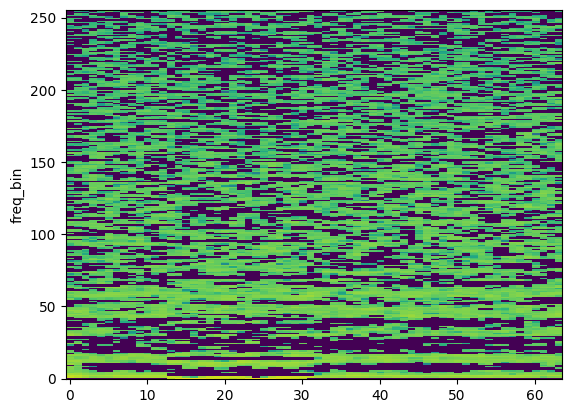

In [38]:
plot_spectrogram(mfcc[0])

In [39]:
dog_and_cat_training_data["mfcc"] = dog_and_cat_training_data["audio"].apply(lambda x: mfcc_transform(x[0])[0])

In [90]:
play_audio(dog_and_cat_training_data["audio"].iloc[80][0], standard_frame_rate)

In [40]:
dog_cat_training = dog_and_cat_training_data[["name", "class", "mfcc"]]

In [41]:
dog_cat_training.loc[dog_cat_training["class"] == "cat", "class"] = 0
dog_cat_training.loc[dog_cat_training["class"] == "dog", "class"] = 1

In [ ]:
dog_cat_write_copy = dog_cat_training.copy()
dog_cat_write_copy["mfcc"] = dog_cat_write_copy["mfcc"].apply(lambda x: x.tolist())
#dog_cat_write_copy.to_csv("dog_cat_training.csv", index=False)

In [43]:
dog_cat_training = pd.read_csv("dog_cat_training.csv")
dog_cat_training["mfcc"] = dog_cat_training["mfcc"].apply(lambda x: torch.tensor(ast.literal_eval(x)))

In [45]:
dog_cat_training

,name,class,mfcc
0,Dog_1.wav,1,"[[tensor(-262.3534), tensor(-135.7012), tensor..."
1,Dog_10.wav,1,"[[tensor(-273.3479), tensor(-145.8717), tensor..."
2,Dog_11.wav,1,"[[tensor(-259.3574), tensor(-134.5800), tensor..."
3,Dog_12.wav,1,"[[tensor(-264.6938), tensor(-133.4479), tensor..."
4,Dog_13.wav,1,"[[tensor(-264.3250), tensor(-138.0634), tensor..."
...,...,...,...
95,Cat_50.wav,0,"[[tensor(-275.5383), tensor(-138.0933), tensor..."
96,Cat_6.wav,0,"[[tensor(-266.5592), tensor(-137.5971), tensor..."
97,Cat_7.wav,0,"[[tensor(-259.4594), tensor(-130.7481), tensor..."
98,Cat_8.wav,0,"[[tensor(-264.2008), tensor(-141.7016), tensor..."


### CNN Model

In [46]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import models
import numpy as np
from sklearn.model_selection import train_test_split
import pandas as pd

# Assuming your DataFrame is called dog_cat_training
# dog_cat_training should have 'mfcc' (MFCC feature matrix) and 'class' (labels)

# Device setup
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

# Define the Dataset class
class AudioDataset(torch.utils.data.Dataset):
    def __init__(self, mfccs, labels):
        self.mfccs = mfccs
        self.labels = labels
    
    def __len__(self):
        return len(self.mfccs)
    
    def __getitem__(self, idx):
        mfcc = torch.tensor(self.mfccs[idx], dtype=torch.float32)  # MFCC is typically 2D: (n_mfcc, n_frames)
        label = torch.tensor(self.labels[idx], dtype=torch.long)  # Ensure label is an integer type
        return mfcc, label

# Prepare data
mfccs = np.array(dog_cat_training['mfcc'].tolist())  # Convert list of arrays to a numpy array
labels = np.array(dog_cat_training['class'].tolist())

# Split data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(mfccs, labels, test_size=0.2, random_state=42)

# Create PyTorch datasets
train_dataset = AudioDataset(X_train, y_train)
val_dataset = AudioDataset(X_val, y_val)

# Create PyTorch dataloaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# Load pre-trained ResNet34 and modify the model
resnet_model = models.resnet34(pretrained=True)

# Modify the first convolutional layer to accept 1 channel (MFCC)
resnet_model.conv1 = nn.Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)

# Modify the final fully connected layer to match the number of classes (2 in your case for binary classification)
resnet_model.fc = nn.Linear(resnet_model.fc.in_features, 2)  # 2 output classes for binary classification

# Move the model to the selected device (GPU or CPU)
resnet_model = resnet_model.to(device)

# Loss function and optimizer
criterion = nn.CrossEntropyLoss()  # Suitable for multi-class classification
optimizer = optim.Adam(resnet_model.parameters(), lr=0.001)

# Training loop
num_epochs = 20
for epoch in range(num_epochs):
    resnet_model.train()  # Set model to training mode
    running_loss = 0.0
    correct = 0
    total = 0
    
    for inputs, labels in train_loader:
        # Add the channel dimension (1 channel, like grayscale)
        inputs = inputs.unsqueeze(1).to(device)  # Shape: (batch_size, 1, 256, 64)
        labels = labels.to(device)
        
        optimizer.zero_grad()  # Zero the parameter gradients
        
        # Forward pass
        outputs = resnet_model(inputs)  
        
        loss = criterion(outputs, labels)  # Calculate loss
        loss.backward()  # Backward pass
        optimizer.step()  # Update weights
        
        running_loss += loss.item()
        
        # Calculate accuracy
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / len(train_loader)
    epoch_accuracy = 100 * correct / total
    
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}, Accuracy: {epoch_accuracy:.2f}%")
    
    # Validation loop (optional)
    if (epoch+1) % 5 == 0:
        resnet_model.eval()  # Set model to evaluation mode
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        
        with torch.no_grad():  # No need to calculate gradients during validation
            for inputs, labels in val_loader:
                inputs = inputs.unsqueeze(1).to(device)  # Add channel dimension (1 channel)
                labels = labels.to(device)
                outputs = resnet_model(inputs)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item()
                
                _, predicted = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()
        
        val_loss = val_loss / len(val_loader)
        val_accuracy = 100 * val_correct / val_total
        print(f"Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_accuracy:.2f}%")

c:\Users\aiden\anaconda3\envs\audio_ml\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\aiden\anaconda3\envs\audio_ml\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet34_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet34_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1/20, Loss: 0.5758, Accuracy: 78.75%
Epoch 2/20, Loss: 0.6603, Accuracy: 75.00%
Epoch 3/20, Loss: 0.3170, Accuracy: 78.75%
Epoch 4/20, Loss: 0.2173, Accuracy: 90.00%
Epoch 5/20, Loss: 0.0685, Accuracy: 97.50%
Validation Loss: 34.6977, Validation Accuracy: 60.00%
Epoch 6/20, Loss: 0.0307, Accuracy: 98.75%
Epoch 7/20, Loss: 0.0078, Accuracy: 100.00%
Epoch 8/20, Loss: 0.0101, Accuracy: 100.00%
Epoch 9/20, Loss: 0.0410, Accuracy: 98.75%
Epoch 10/20, Loss: 0.0309, Accuracy: 98.75%
Validation Loss: 1.7930, Validation Accuracy: 70.00%
Epoch 11/20, Loss: 0.0469, Accuracy: 98.75%
Epoch 12/20, Loss: 0.0071, Accuracy: 100.00%
Epoch 13/20, Loss: 0.1715, Accuracy: 93.75%
Epoch 14/20, Loss: 0.0084, Accuracy: 100.00%
Epoch 15/20, Loss: 0.0800, Accuracy: 98.75%
Validation Loss: 0.5272, Validation Accuracy: 90.00%
Epoch 16/20, Loss: 0.0080, Accuracy: 100.00%
Epoch 17/20, Loss: 0.0184, Accuracy: 100.00%
Epoch 18/20, Loss: 0.0228, Accuracy: 100.00%
Epoch 19/20, Loss: 0.0054, Accuracy: 100.00%
Epoch

### Test and save model

In [26]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

In [58]:
if resnet_model:
    model = resnet_model
else:
    model = torch.load("cat_dog_model.pth", weights_only=False)

In [59]:
old_model = torch.load("cat_dog_model.pth", weights_only=False)

In [63]:
test_sound = audio_formatting("dog_mic_recording.wav", standard_frame_rate, max_duration_ms)

In [64]:
play_audio(*test_sound)

In [ ]:
test_mfcc = mfcc_transform(test_sound[0])
test_mfcc = test_mfcc.unsqueeze(0).to(device)

In [66]:
with torch.no_grad():
    output = model(test_mfcc)
    
_, predicted_class = torch.max(output, 1)

In [67]:
"cat" if predicted_class == 0 else "dog"

'dog'

In [98]:
import os

folder_path = "./test_data_on_mic"
for filename in os.listdir(folder_path):
    file_path = folder_path + "/" + filename
    test_sound = audio_formatting(file_path, standard_frame_rate, max_duration_ms)
    test_mfcc = mfcc_transform(test_sound[0])
    test_mfcc = test_mfcc.unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(test_mfcc)
        
        _, predicted_class = torch.max(output, 1)
    guess = "cat" if predicted_class == 0 else "dog"

    print(guess)
    if filename[:3] == guess:
        print("Correct")
    else:
        print("Incorrect")


cat
Correct
cat
Correct
cat
Correct
cat
Correct
cat
Correct
dog
Correct
dog
Correct
cat
Incorrect
dog
Correct
dog
Correct


In [ ]:
import torch
import onnx

input_tensor = torch.rand((1, 1, 256, 64), dtype=torch.float32)
ONNX_PATH = "./dog_cat_model.onnx"
torch.onnx.export(model=model,
                  args=input_tensor,
                  f=ONNX_PATH,
                  verbose=False,
                  export_params=True,
                  do_constant_folding=False,
                  input_names=['input'],
                  output_names=['output'],
                  opset_version=12
                  )

: 

In [ ]:
#torch.onnx.export(model, torch.randn(input_shape)

In [77]:
torch.save(resnet_model, "cat_dog_model_noise.pth")